# Initial Setup

Before beginning the assignment, we import the CIFAR dataset, and train a simple convolutional neural network (CNN) to classify it.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from typing import Tuple, List

**Reminder:** set the runtime type to "GPU", or your code will run much more slowly on a CPU.

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('Using device:', device)

Using device: cuda


Load training and test data from the CIFAR10 dataset.

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

Define a simple CNN that classifies CIFAR images.

In [4]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, bias=False)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5, bias=False)
        self.fc1   = nn.Linear(16 * 5 * 5, 120, bias=False)
        self.fc2   = nn.Linear(120, 84, bias=False)
        self.fc3   = nn.Linear(84, 10, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net().to(device)

Train this CNN on the training dataset (this may take a few moments).

In [5]:
from torch.utils.data import DataLoader

def train(model: nn.Module, dataloader: DataLoader):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

    for epoch in range(2):  # loop over the dataset multiple times
        running_loss = 0.0
        for i, data in enumerate(dataloader, 0):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if i % 2000 == 1999:
                print('[%d, %5d] loss: %.3f' % (epoch + 1, i + 1, running_loss / 2000))
                running_loss = 0.0

    print('Finished Training')


def test(model: nn.Module, dataloader: DataLoader, max_samples=None) -> float:
    correct = 0
    total = 0
    n_inferences = 0

    with torch.no_grad():
        for data in dataloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if max_samples:
                n_inferences += images.shape[0]
                if n_inferences > max_samples:
                    break

    return 100 * correct / total

In [6]:
train(net, trainloader)

[1,  2000] loss: 2.235
[1,  4000] loss: 1.891
[1,  6000] loss: 1.710
[1,  8000] loss: 1.604
[1, 10000] loss: 1.530
[1, 12000] loss: 1.492
[2,  2000] loss: 1.400
[2,  4000] loss: 1.404
[2,  6000] loss: 1.377
[2,  8000] loss: 1.342
[2, 10000] loss: 1.342
[2, 12000] loss: 1.322
Finished Training


Now that the CNN has been trained, let's test it on our test dataset.

In [7]:
score = test(net, testloader)
print('Accuracy of the network on the test images: {}%'.format(score))

Accuracy of the network on the test images: 52.7%


In [8]:
# A convenience function which we use to copy CNNs
def copy_model(model: nn.Module) -> nn.Module:
    result = deepcopy(model)

    if hasattr(model, 'input_activations'):
        result.input_activations = deepcopy(model.input_activations)

    for result_layer, original_layer in zip(result.children(), model.children()):
        if isinstance(result_layer, nn.Conv2d) or isinstance(result_layer, nn.Linear):
            if hasattr(original_layer.weight, 'scale'):
                result_layer.weight.scale = deepcopy(original_layer.weight.scale)
            if hasattr(original_layer, 'activations'):
                result_layer.activations = deepcopy(original_layer.activations)
            if hasattr(original_layer, 'output_scale'):
                result_layer.output_scale = deepcopy(original_layer.output_scale)

    return result

# Question 1: Visualize Weights

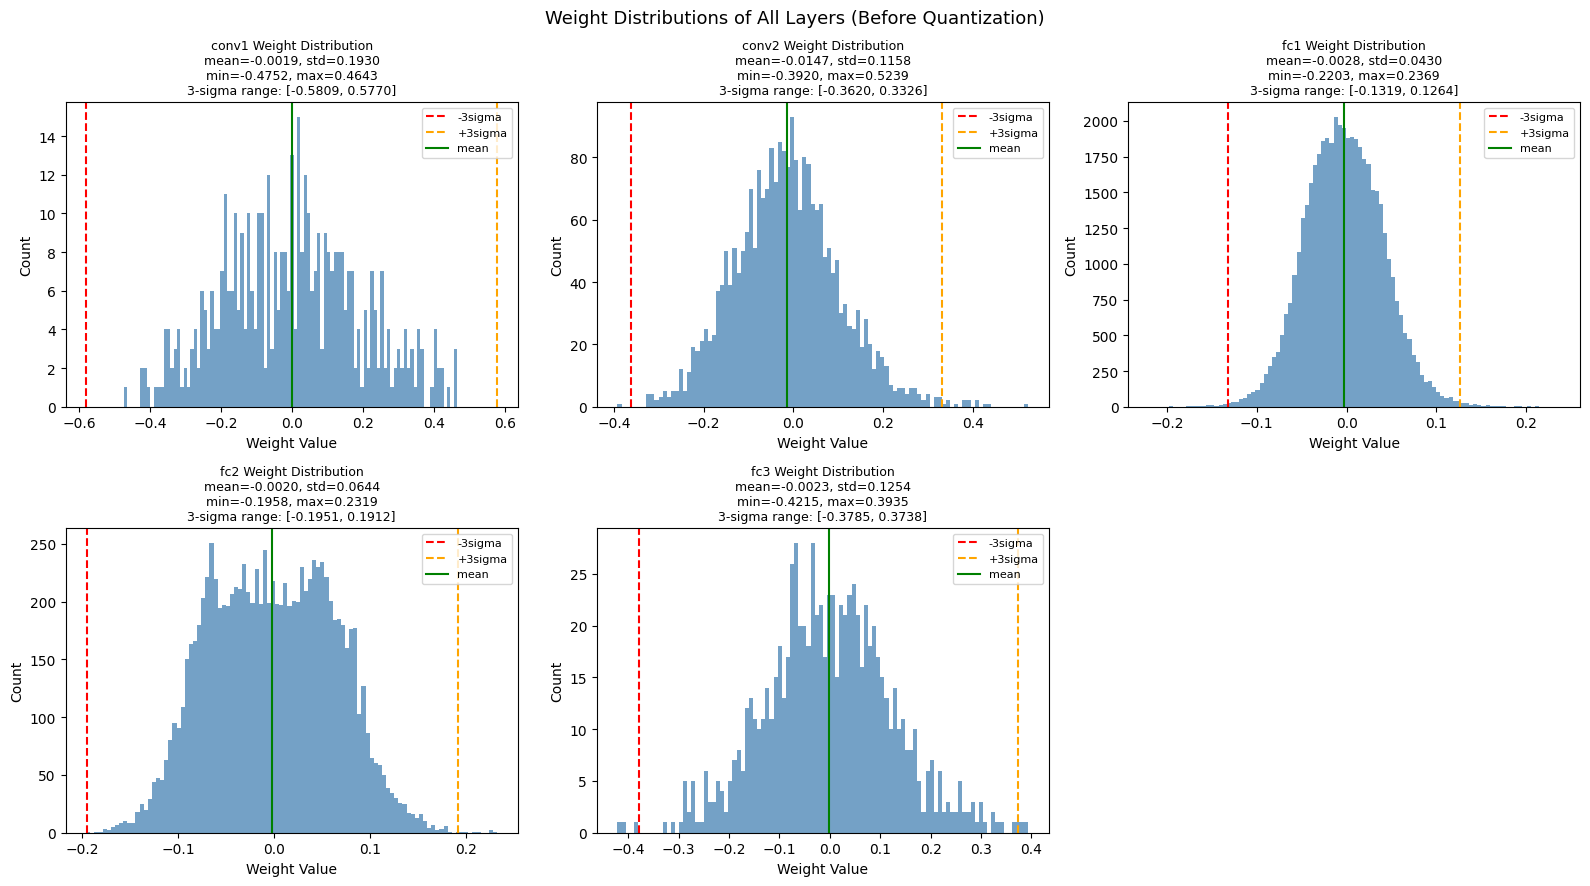

Figure saved to q1_weight_distributions.png


In [9]:
# ------------------------------------------------------------------
# Q1: Plot the weight distributions of every layer in the network.
# ------------------------------------------------------------------

# Collect the flattened weight tensors (moved to CPU as numpy arrays)
layers_weights = [
    ('conv1', net.conv1.weight.data.cpu().view(-1).numpy()),
    ('conv2', net.conv2.weight.data.cpu().view(-1).numpy()),
    ('fc1',   net.fc1.weight.data.cpu().view(-1).numpy()),
    ('fc2',   net.fc2.weight.data.cpu().view(-1).numpy()),
    ('fc3',   net.fc3.weight.data.cpu().view(-1).numpy()),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (name, weights) in enumerate(layers_weights):
    ax = axes[idx]
    mean = np.mean(weights)
    std  = np.std(weights)

    # Plot histogram of weight values (100 bins for fine granularity)
    ax.hist(weights, bins=100, color='steelblue', alpha=0.75, edgecolor='none')

    # Mark the +/-3 sigma boundaries (covers ~99.7% of a Gaussian distribution)
    ax.axvline(mean - 3 * std, color='red',    linestyle='--', linewidth=1.5, label='-3sigma')
    ax.axvline(mean + 3 * std, color='orange', linestyle='--', linewidth=1.5, label='+3sigma')
    ax.axvline(mean,           color='green',  linestyle='-',  linewidth=1.5, label='mean')

    # Annotate with key statistics
    title = (
        f'{name} Weight Distribution\n'
        f'mean={mean:.4f}, std={std:.4f}\n'
        f'min={weights.min():.4f}, max={weights.max():.4f}\n'
        f'3-sigma range: [{mean-3*std:.4f}, {mean+3*std:.4f}]'
    )
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

# Hide the unused 6th subplot
axes[-1].set_visible(False)

plt.suptitle('Weight Distributions of All Layers (Before Quantization)', fontsize=13)
plt.tight_layout()
plt.savefig('q1_weight_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to q1_weight_distributions.png')

# Question 2: Quantize Weights

In [10]:
net_q2 = copy_model(net)

In [11]:
def quantized_weights(weights: torch.Tensor) -> Tuple[torch.Tensor, float]:
    '''
    Quantize the weights so that all values are integers between -128 and 127.

    Strategy: 3-sigma scaling.
      - Compute the standard deviation of the weight distribution.
      - Choose scale = 127 / (3 * sigma) so that +/-3 sigma maps to +/-127.
      - Multiply every weight by this scale, round to the nearest integer,
        and clamp to the signed 8-bit range [-128, 127].
      - Values beyond +/-3 sigma are statistical outliers (~0.3% of data);
        clamping them avoids wasting dynamic range on rare extremes.

    Parameters:
      weights (Tensor): float32 weights from a trained layer

    Returns:
      (Tensor, float): tuple of
        * quantized weights (float dtype, all values are integers in [-128, 127])
        * the scale factor used (float weight * scale = integer weight)
    '''
    # Compute the standard deviation of all weight values
    sigma = weights.std().item()

    # Scale so that 3 standard deviations span the full int8 positive range (127)
    scale = 127.0 / (3.0 * sigma)

    # Multiply, round to nearest integer, then clamp to signed 8-bit bounds
    result = (weights * scale).round()
    result = torch.clamp(result, min=-128, max=127)

    return result, scale

In [12]:
def quantize_layer_weights(model: nn.Module):
    '''Apply quantized_weights() to every Conv2d and Linear layer in the model.'''
    for layer in model.children():
        if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear):
            q_layer_data, scale = quantized_weights(layer.weight.data)
            q_layer_data = q_layer_data.to(device)

            layer.weight.data  = q_layer_data
            layer.weight.scale = scale          # store scale for later use

            # Sanity checks
            if (q_layer_data < -128).any() or (q_layer_data > 127).any():
                raise Exception(
                    f'Quantized weights of {layer.__class__.__name__} are out of int8 range')
            if (q_layer_data != q_layer_data.round()).any():
                raise Exception(
                    f'Quantized weights of {layer.__class__.__name__} are not integers')

quantize_layer_weights(net_q2)

In [13]:
score = test(net_q2, testloader)
print('Accuracy of the network after quantizing all weights: {}%'.format(score))

Accuracy of the network after quantizing all weights: 53.12%


# Question 3: Visualize Activations

In [14]:
def register_activation_profiling_hooks(model):
    '''
    Register PyTorch forward hooks that record the input / output activations
    of each layer during a forward pass.

    The hook on convN records the INPUT to convN (i.e., the OUTPUT of the
    previous stage), matching the storage attributes on the model:
      model.input_activations   -> raw pixel inputs (input to conv1)
      model.conv1.activations   -> output of pool(relu(conv1))  [= input to conv2]
      model.conv2.activations   -> output of pool(relu(conv2))  [= input to fc1]
      model.fc1.activations     -> output of relu(fc1)          [= input to fc2]
      model.fc2.activations     -> output of relu(fc2)          [= input to fc3]
      model.fc3.activations     -> output of fc3 (logits)
    '''
    model.input_activations   = np.empty(0)
    model.conv1.activations   = np.empty(0)
    model.conv2.activations   = np.empty(0)
    model.fc1.activations     = np.empty(0)
    model.fc2.activations     = np.empty(0)
    model.fc3.activations     = np.empty(0)

    model.profile_activations = True

    def conv1_hook(layer, x, y):
        if model.profile_activations:
            # x[0] is the input tensor to conv1 = raw image pixels
            model.input_activations = np.append(model.input_activations, x[0].cpu().view(-1))
    model.conv1.register_forward_hook(conv1_hook)

    def conv2_hook(layer, x, y):
        if model.profile_activations:
            # x[0] is the input to conv2 = output of pool(relu(conv1))
            model.conv1.activations = np.append(model.conv1.activations, x[0].cpu().view(-1))
    model.conv2.register_forward_hook(conv2_hook)

    def fc1_hook(layer, x, y):
        if model.profile_activations:
            # x[0] is the input to fc1 = output of pool(relu(conv2)) (flattened)
            model.conv2.activations = np.append(model.conv2.activations, x[0].cpu().view(-1))
    model.fc1.register_forward_hook(fc1_hook)

    def fc2_hook(layer, x, y):
        if model.profile_activations:
            # x[0] is the input to fc2 = output of relu(fc1)
            model.fc1.activations = np.append(model.fc1.activations, x[0].cpu().view(-1))
    model.fc2.register_forward_hook(fc2_hook)

    def fc3_hook(layer, x, y):
        if model.profile_activations:
            # x[0] = input to fc3 = output of relu(fc2)
            model.fc2.activations = np.append(model.fc2.activations, x[0].cpu().view(-1))
            # y is the output tensor of fc3 (the final logits)
            model.fc3.activations = np.append(model.fc3.activations, y.cpu().view(-1))
    model.fc3.register_forward_hook(fc3_hook)

In [15]:
net_q3 = copy_model(net)
register_activation_profiling_hooks(net_q3)

# Run a subset of the training data through the unquantized model to collect activations.
# We do not need gradients here, so the test() function is reused.
test(net_q3, trainloader, max_samples=400)
net_q3.profile_activations = False   # stop collecting after the profiling pass

In [16]:
# Convenience references to the collected activation arrays
input_activations        = net_q3.input_activations
conv1_output_activations = net_q3.conv1.activations
conv2_output_activations = net_q3.conv2.activations
fc1_output_activations   = net_q3.fc1.activations
fc2_output_activations   = net_q3.fc2.activations
fc3_output_activations   = net_q3.fc3.activations

----------------------------------------------------------------------------
Layer                             Min      Max     Mean      Std  3-sigma range
----------------------------------------------------------------------------
Input (to conv1)               -1.000    1.000   -0.055    0.499  [-1.551, 1.442]
conv1 Output (to conv2)         0.000    9.027    0.565    0.804  [-1.847, 2.977]
conv2 Output (to fc1)           0.000   15.806    0.677    1.191  [-2.896, 4.251]
fc1 Output (to fc2)             0.000   11.023    0.471    0.991  [-2.502, 3.444]
fc2 Output (to fc3)             0.000    7.921    0.380    0.713  [-1.758, 2.518]
fc3 Output (logits)            -9.343   11.750   -0.070    2.462  [-7.456, 7.316]
----------------------------------------------------------------------------


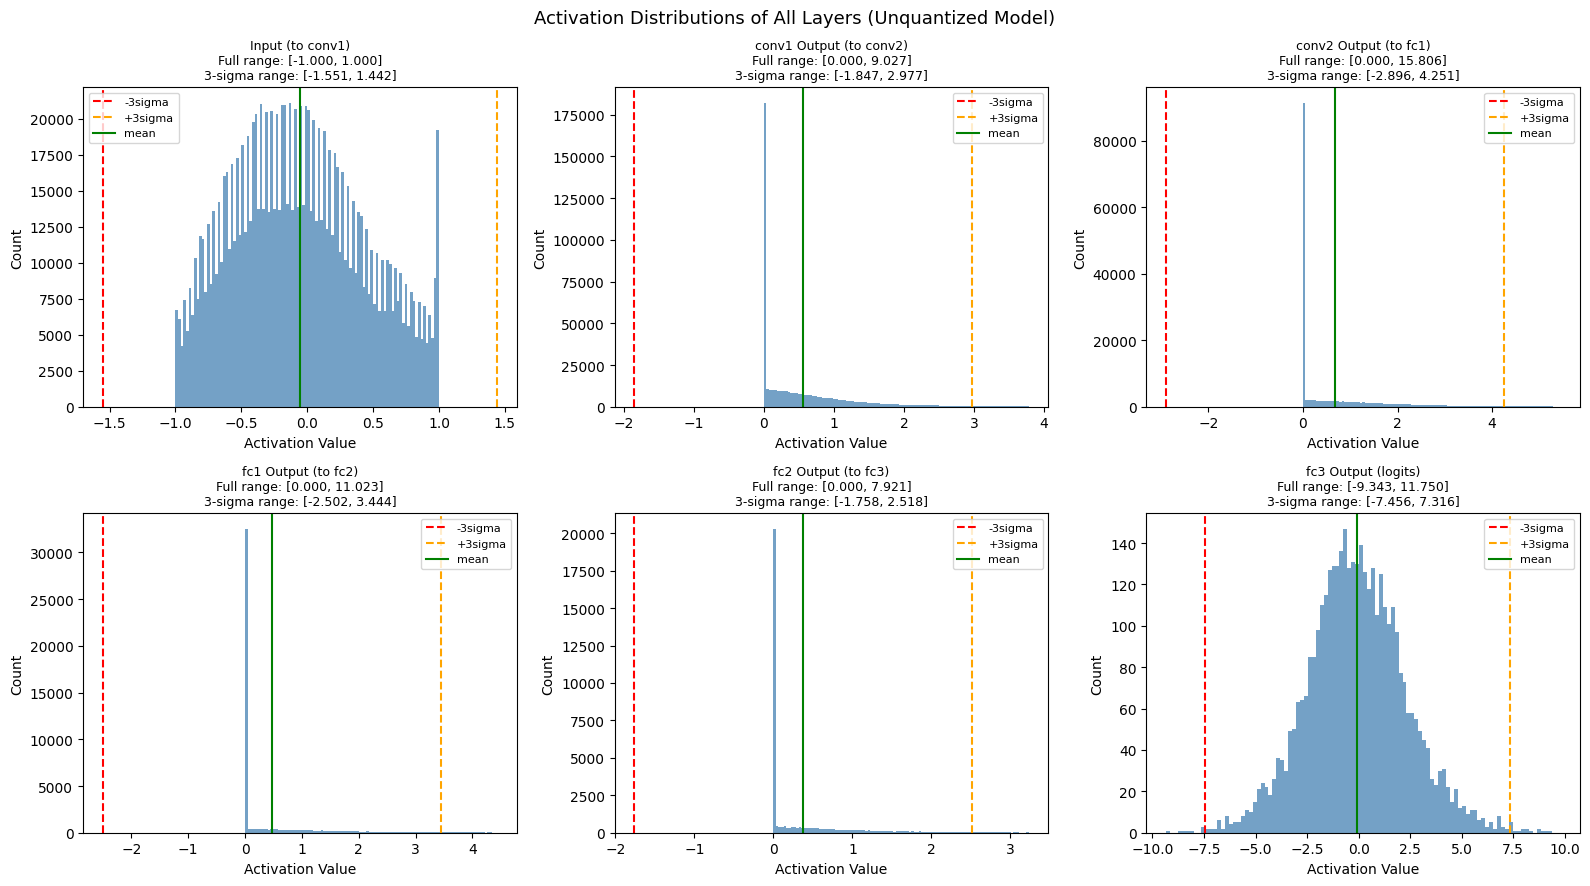

Figure saved to q3_activation_distributions.png


In [17]:
# ------------------------------------------------------------------
# Q3: Plot activation distributions and print summary statistics.
# ------------------------------------------------------------------

activations_info = [
    ('Input (to conv1)',        input_activations),
    ('conv1 Output (to conv2)', conv1_output_activations),
    ('conv2 Output (to fc1)',   conv2_output_activations),
    ('fc1 Output (to fc2)',     fc1_output_activations),
    ('fc2 Output (to fc3)',     fc2_output_activations),
    ('fc3 Output (logits)',     fc3_output_activations),
]

# Print a concise summary table
print('-' * 76)
print(f'{"Layer":<28}  {"Min":>7}  {"Max":>7}  {"Mean":>7}  {"Std":>7}  3-sigma range')
print('-' * 76)
for name, acts in activations_info:
    mean = np.mean(acts)
    std  = np.std(acts)
    print(f'{name:<28}  {np.min(acts):>7.3f}  {np.max(acts):>7.3f}  '
          f'{mean:>7.3f}  {std:>7.3f}  [{mean-3*std:.3f}, {mean+3*std:.3f}]')
print('-' * 76)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (name, acts) in enumerate(activations_info):
    ax = axes[idx]
    mean = np.mean(acts)
    std  = np.std(acts)

    # Clip the histogram x-range to +/-4 sigma for visual clarity
    clip_lo = max(mean - 4 * std, np.min(acts))
    clip_hi = min(mean + 4 * std, np.max(acts))
    ax.hist(acts, bins=100, range=(clip_lo, clip_hi),
            color='steelblue', alpha=0.75, edgecolor='none')

    # Mark +/-3 sigma: values outside this band will be clipped when quantizing
    ax.axvline(mean - 3*std, color='red',    linestyle='--', linewidth=1.5, label='-3sigma')
    ax.axvline(mean + 3*std, color='orange', linestyle='--', linewidth=1.5, label='+3sigma')
    ax.axvline(mean,         color='green',  linestyle='-',  linewidth=1.5, label='mean')

    title = (
        f'{name}\n'
        f'Full range: [{np.min(acts):.3f}, {np.max(acts):.3f}]\n'
        f'3-sigma range: [{mean-3*std:.3f}, {mean+3*std:.3f}]'
    )
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Activation Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Activation Distributions of All Layers (Unquantized Model)', fontsize=13)
plt.tight_layout()
plt.savefig('q3_activation_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to q3_activation_distributions.png')

# Question 4: Quantize Activations

In [18]:
class NetQuantized(nn.Module):
    '''
    A CNN that runs simulated 8-bit integer inference.

    Key idea:
      All weights and activations are kept as integers in [-128, 127].
      The forward pass applies each layer, then rescales (via output_scale)
      so the output fits back in int8 for the next layer.

    Scale accounting (per layer l):
      accumulated_l = n_0 * n_w_1 * n_out_1 * ... * n_w_l
      where:
        n_0       = input_scale       (maps raw pixels to int8)
        n_w_l     = layer.weight.scale (maps float weights to int8)
        n_out_l   = layer.output_scale (maps accumulated int values back to int8)
    '''

    def __init__(self, net_with_weights_quantized: nn.Module):
        super(NetQuantized, self).__init__()

        net_init = copy_model(net_with_weights_quantized)

        self.conv1 = net_init.conv1
        self.pool  = net_init.pool
        self.conv2 = net_init.conv2
        self.fc1   = net_init.fc1
        self.fc2   = net_init.fc2
        self.fc3   = net_init.fc3

        # Register pre-hooks that verify every layer input is a valid int8 tensor
        for layer in self.conv1, self.conv2, self.fc1, self.fc2, self.fc3:
            def pre_hook(l, x):
                x = x[0]
                if (x < -128).any() or (x > 127).any():
                    raise Exception(
                        f'Input to {l.__class__.__name__} is out of int8 range')
                if (x != x.round()).any():
                    raise Exception(
                        f'Input to {l.__class__.__name__} has non-integer values')
            layer.register_forward_pre_hook(pre_hook)

        # Compute the input scale from the profiled pixel distribution
        self.input_activations = net_with_weights_quantized.input_activations
        self.input_scale = NetQuantized.quantize_initial_input(self.input_activations)

        # Compute output scales for each layer in order (each layer needs the scales
        # of all preceding layers, so we build the list incrementally)
        preceding_layer_scales = []
        for layer in self.conv1, self.conv2, self.fc1, self.fc2, self.fc3:
            layer.output_scale = NetQuantized.quantize_activations(
                layer.activations,
                layer.weight.scale,
                self.input_scale,
                preceding_layer_scales
            )
            preceding_layer_scales.append((layer.weight.scale, layer.output_scale))

    @staticmethod
    def quantize_initial_input(pixels: np.ndarray) -> float:
        '''
        Compute a scale factor n_0 for the raw input images.

        After normalization, CIFAR pixels live in [-1, 1] with std ~ 0.5.
        We choose n_0 = 127 / (3 * sigma) so that +/-3 sigma maps to +/-127,
        keeping ~99.7% of values in the valid int8 range.

        Parameters:
          pixels: all pixel values seen during the profiling pass

        Returns:
          float: n_0  (quantized pixel = round(raw_pixel * n_0))
        '''
        sigma = np.std(pixels)
        # Scale so that 3 sigma spans the positive int8 range (127)
        scale = 127.0 / (3.0 * sigma)
        return scale

    @staticmethod
    def quantize_activations(
        activations: np.ndarray,
        n_w: float,
        n_initial_input: float,
        ns: List[Tuple[float, float]]
    ) -> float:
        '''
        Compute the output rescaling factor (output_scale) for one layer.

        After the integer multiply-accumulate W_int * X_int, the result
        represents float_output * accumulated_scale, where:

            accumulated_scale = n_initial_input * n_w
                                * product_over_preceding_layers(n_w_prev * n_out_prev)

        We choose output_scale so that:
            float_activation * accumulated_scale * output_scale  fits in [-127, 127].

        Using 3-sigma: output_scale = 127 / (3 * sigma * accumulated_scale).

        Parameters:
          activations     : float outputs of this layer (from profiling run)
          n_w             : weight scale of this layer
          n_initial_input : scale applied to the very first CNN input (n_0)
          ns              : [(n_w_prev, n_out_prev), ...] for all preceding layers

        Returns:
          float: output_scale for this layer
        '''
        # Step 1: build the accumulated scale from the input through this layer's weights
        accumulated_scale = n_initial_input * n_w   # contribution of input and current weights

        # Multiply in the (weight_scale * output_scale) of every preceding layer.
        # Each preceding layer already rescaled its output by n_out_prev, so the
        # integer value entering the current layer represents float * n_out_prev * n_w_prev.
        for (n_w_prev, n_out_prev) in ns:
            accumulated_scale *= n_w_prev * n_out_prev

        # Step 2: use the 3-sigma range of the float activations to choose output_scale
        sigma = np.std(activations)
        if sigma == 0:
            # All activations are zero (e.g., fully clipped by ReLU): any scale works
            return 1.0

        output_scale = 127.0 / (3.0 * sigma * accumulated_scale)
        return output_scale

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        '''
        Quantized forward pass.

        Pattern at each layer:
          1. Apply the layer (simulated integer multiply-accumulate in float32).
          2. Apply nonlinearity (ReLU) and/or pooling.
          3. Rescale: multiply by output_scale, round to int, clamp to [-128, 127].
             This maps the large accumulated integer values back to int8 so the
             next layer's pre-hook validation passes.

        The final fc3 output (logits) does not need to be quantized.
        '''
        # --- Quantize raw float input to int8 ---
        # raw pixel value * input_scale -> round -> clamp to [-128, 127]
        x = (x * self.input_scale).round().clamp(-128, 127)

        # --- conv1: int8 convolution -> ReLU -> MaxPool -> rescale to int8 ---
        x = self.conv1(x)                                            # simulated int MAC
        x = F.relu(x)                                                # non-negativity constraint
        x = self.pool(x)                                             # 2x2 max pooling
        x = (x * self.conv1.output_scale).round().clamp(-128, 127)  # re-quantize to int8

        # --- conv2: int8 convolution -> ReLU -> MaxPool -> rescale to int8 ---
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        x = (x * self.conv2.output_scale).round().clamp(-128, 127)

        # --- Flatten spatial feature map for fully-connected layers ---
        x = x.view(-1, 16 * 5 * 5)

        # --- fc1: int8 linear -> ReLU -> rescale to int8 ---
        x = self.fc1(x)
        x = F.relu(x)
        x = (x * self.fc1.output_scale).round().clamp(-128, 127)

        # --- fc2: int8 linear -> ReLU -> rescale to int8 ---
        x = self.fc2(x)
        x = F.relu(x)
        x = (x * self.fc2.output_scale).round().clamp(-128, 127)

        # --- fc3: final classification layer; output logits (no re-quantization needed) ---
        x = self.fc3(x)
        return x

In [19]:
# Merge the quantized weights (net_q2) with the activation profiles (net_q3)
net_init = copy_model(net_q2)
net_init.input_activations = deepcopy(net_q3.input_activations)

for layer_init, layer_q3 in zip(net_init.children(), net_q3.children()):
    if isinstance(layer_init, nn.Conv2d) or isinstance(layer_init, nn.Linear):
        layer_init.activations = deepcopy(layer_q3.activations)

net_quantized = NetQuantized(net_init)

In [20]:
score = test(net_quantized, testloader)
print('Accuracy of the network after quantizing both weights and activations: {}%'.format(score))

Accuracy of the network after quantizing both weights and activations: 52.84%


# Question 5: Quantize Biases

In [21]:
class NetWithBias(nn.Module):
    '''
    Same architecture as Net, but fc3 includes a learnable bias term.
    A bias is the simplest example of a parameter that must share the same
    integer scale as the weight-input dot product.
    '''
    def __init__(self):
        super(NetWithBias, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, bias=False)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5, bias=False)
        self.fc1   = nn.Linear(16 * 5 * 5, 120, bias=False)
        self.fc2   = nn.Linear(120, 84, bias=False)
        self.fc3   = nn.Linear(84, 10, bias=True)   # <-- bias enabled only here

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net_with_bias = NetWithBias().to(device)

In [22]:
train(net_with_bias, trainloader)

[1,  2000] loss: 2.217
[1,  4000] loss: 1.899
[1,  6000] loss: 1.724
[1,  8000] loss: 1.634
[1, 10000] loss: 1.561
[1, 12000] loss: 1.512
[2,  2000] loss: 1.441
[2,  4000] loss: 1.438
[2,  6000] loss: 1.382
[2,  8000] loss: 1.398
[2, 10000] loss: 1.342
[2, 12000] loss: 1.340
Finished Training


In [23]:
score = test(net_with_bias, testloader)
print('Accuracy of the network (with a bias) on the test images: {}%'.format(score))

Accuracy of the network (with a bias) on the test images: 51.24%


In [24]:
# Profile activations of the bias-enabled model using the same hooks
register_activation_profiling_hooks(net_with_bias)
test(net_with_bias, trainloader, max_samples=400)
net_with_bias.profile_activations = False

In [25]:
# Quantize only the weights of net_with_bias (leave the bias in float for now)
net_with_bias_with_quantized_weights = copy_model(net_with_bias)
quantize_layer_weights(net_with_bias_with_quantized_weights)

score = test(net_with_bias_with_quantized_weights, testloader)
print("Accuracy after quantizing weights but NOT the bias: {}%".format(score))

Accuracy after quantizing weights but NOT the bias: 46.56%


In [26]:
class NetQuantizedWithBias(NetQuantized):
    '''
    Extends NetQuantized to also quantize the bias of fc3.

    Why 32-bit for biases?
    ----------------------
    In integer hardware, the bias is added into the same 32-bit accumulator
    that holds the weight-input dot product.  The bias therefore needs to be
    on the same scale as that accumulator (not the int8 output scale).
    This is why biases use int32 instead of int8.
    '''

    def __init__(self, net_with_weights_quantized: nn.Module):
        # The parent __init__ handles weight + activation quantization
        super(NetQuantizedWithBias, self).__init__(net_with_weights_quantized)

        # Collect the (weight_scale, output_scale) pairs for all layers BEFORE fc3.
        # These are needed to compute the same accumulated scale used by the dot product.
        preceding_scales = [
            (layer.weight.scale, layer.output_scale)
            for layer in self.children()
            if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear)
        ][:-1]   # [:-1] excludes fc3 (whose bias we are quantizing)

        # Quantize the fc3 bias with the same accumulated scale as its weight multiply
        self.fc3.bias.data = NetQuantizedWithBias.quantized_bias(
            self.fc3.bias.data,
            self.fc3.weight.scale,
            self.input_scale,
            preceding_scales
        )

        # Validation: check the quantized bias is within int32 range and is integer-valued
        if (self.fc3.bias.data < -2147483648).any() or (self.fc3.bias.data > 2147483647).any():
            raise Exception('Bias values are out of int32 range')
        if (self.fc3.bias.data != self.fc3.bias.data.round()).any():
            raise Exception('Bias has non-integer values')

    @staticmethod
    def quantized_bias(
        bias: torch.Tensor,
        n_w: float,
        n_initial_input: float,
        ns: List[Tuple[float, float]]
    ) -> torch.Tensor:
        '''
        Quantize a bias vector to integers in the 32-bit signed range.

        Background:
        -----------
        The integer dot product W_int * X_int for fc3 represents:
            float_output * (n_initial_input * n_w * product(n_w_prev * n_out_prev))
                         = float_output * accumulated_scale

        The bias is added to this same accumulator, so it must be scaled by
        the identical accumulated_scale:
            bias_int = round(bias_float * accumulated_scale)

        Parameters:
          bias            : float32 bias from the trained model (shape: [out_features])
          n_w             : weight scale of fc3
          n_initial_input : scale applied to the very first CNN input
          ns              : [(n_w_prev, n_out_prev), ...] for all layers before fc3

        Returns:
          Tensor: bias quantized to int32 range (float dtype, integer values)
        '''
        # Build the same accumulated scale used by the weight-input dot product
        accumulated_scale = n_initial_input * n_w
        for (n_w_prev, n_out_prev) in ns:
            accumulated_scale *= n_w_prev * n_out_prev

        # Scale the float bias, round to nearest integer, clamp to int32 bounds
        bias_q = (bias * accumulated_scale).round()
        return torch.clamp(bias_q, min=-2147483648, max=2147483647)

In [27]:
net_quantized_with_bias = NetQuantizedWithBias(net_with_bias_with_quantized_weights)

In [28]:
score = test(net_quantized_with_bias, testloader)
print('Accuracy after quantizing both weights AND bias: {}%'.format(score))

Accuracy after quantizing both weights AND bias: 49.54%
